In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

np.random.seed(42) # for reproducibility


## Data preparation

In [3]:
spect = np.load('spectrums.npy')    # spectra, wavelengths, uncertainties - input data
label = pd.read_csv('FM_Parameter_Table.csv') # labels - data we want to predict

wavelengths = spect[ 0, :, 0]
spectrum = spect[:, :, 1]

wavelengths.shape

(52,)

Let's see how the spectra normalized to their mean values look like

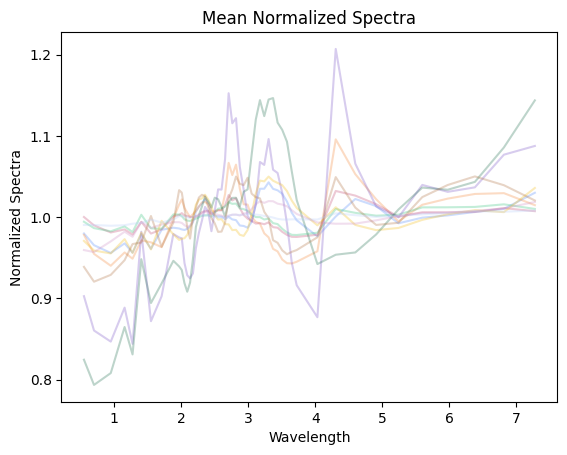

In [4]:
rand_ids = np.random.choice(len(spectrum), 10)
for i in rand_ids:
    plt.plot(wavelengths, spectrum[i]/np.mean(spectrum[i]), alpha=0.3)

plt.title('Mean Normalized Spectra')
plt.ylabel('Normalized Spectra')
plt.xlabel('Wavelength')
plt.show()


In [5]:
param_names = ['planet_radius', 'planet_temp', 'log_H2O','log_CO2', 'log_CO', 'log_CH4', 'log_NH3'] # We keep the labels for further plots
output = label[param_names].values

In [6]:
def our_min_max(data, axis=1):
    """
    Normalize data to [0,1], saving normalization coefficients
    """
    norm_k = (np.max(data, axis=axis) - np.min(data, axis=axis)).reshape(-1,1)
    res = (data - np.min(data, axis=axis).reshape(-1,1))/norm_k
    return res, norm_k

Data normalization

In [7]:
y_scaler = MinMaxScaler()
y_norm = y_scaler.fit_transform(output)

X_norm, norm_koeffs = our_min_max(spectrum)

input_data = X_norm.copy()
input_data.shape

(41423, 52)

Now let's see how our final version (min-max normalized) of input spectra looks like

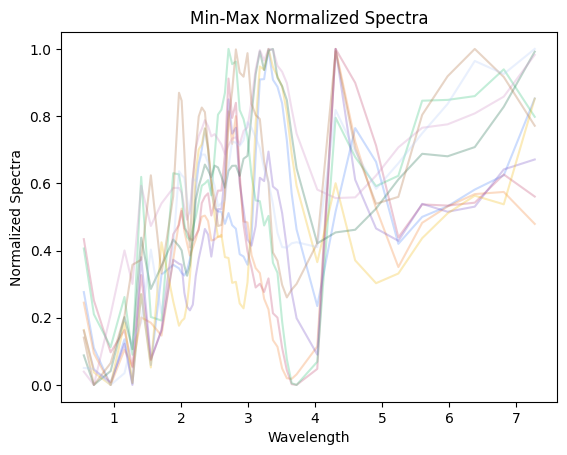

In [8]:
for i in rand_ids:
    plt.plot(wavelengths, X_norm[i], alpha=0.3)

plt.title('Min-Max Normalized Spectra')
plt.ylabel('Normalized Spectra')
plt.xlabel('Wavelength')
plt.show()


We keep 10% of the initial dataset as validation (test) data

In [9]:
X_train, X_test, y_train, y_test = train_test_split(input_data, y_norm, test_size=0.1, random_state=1)

input_data.shape[1]

52

## CNN setup and training

In [11]:
callback = keras.callbacks.EarlyStopping(monitor = 'loss', patience=3)
n = output.shape[1]
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(input_data.shape[1], 1)),
    tf.keras.layers.Conv1D(53, 3,1, padding = 'same', activation='relu'),
    tf.keras.layers.MaxPooling1D(2),
    tf.keras.layers.Conv1D(64, 3,1, padding = 'same', activation='relu'),
    tf.keras.layers.MaxPooling1D(2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(n)
])


model.compile(optimizer='adam',
              loss='mse',
              metrics=['mae'])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 52, 53)         │           212 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 26, 53)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 26, 64)         │        10,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 13, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 832)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        53,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 64,219 (250.86 KB)

 Trainable params: 64,219 (250.86 KB)

 Non-trainable params: 0 (0.00 B)

We train our neural network and keep the trainig history

In [13]:
history = model.fit(X_train, y_train, validation_data = (X_test, y_test),
          epochs=100, shuffle=True, callbacks=[callback],
          batch_size=200)

Epoch 1/100
187/187 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 0.0335 - mae: 0.1382 - val_loss: 0.0177 - val_mae: 0.0983
Epoch 2/100
187/187 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.0146 - mae: 0.0874 - val_loss: 0.0132 - val_mae: 0.0813
Epoch 3/100
187/187 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0115 - mae: 0.0752 - val_loss: 0.0107 - val_mae: 0.0717
Epoch 4/100
187/187 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0098 - mae: 0.0686 - val_loss: 0.0095 - val_mae: 0.0667
Epoch 5/100
187/187 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0088 - mae: 0.0645 - val_loss: 0.0090 - val_mae: 0.0660
Epoch 6/100
187/187 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0081 - mae: 0.0612 - val_loss: 0.0088 - val_mae: 0.0635
Epoch 7/100
187/187 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0075 - mae: 0.0585 - val_loss: 0.0079 - val_mae: 0.0615
Epoch 8/100
187/187 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.0071 - mae: 0.0566 - val_loss: 0.0073 - val_mae: 0.0577
Epoch 9/100
187/187 ━━━━━━━━━━━━━━━━━━━━

We use mean squared error of the __normalized__ data as a measurement of CNN performance on our test data

In [14]:
y_pred = model.predict(X_test)
loss, accuracy  = model.evaluate(X_test, y_test)
quality = np.sum((y_pred-y_test)**2, axis=0)/y_test.shape[0]


130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0033 - mae: 0.0334


For illustration purposes we restore the original range of physical parameters

In [15]:
y_test_phys = y_scaler.inverse_transform(y_test)
y_pred_phys = y_scaler.inverse_transform(y_pred)

## Results

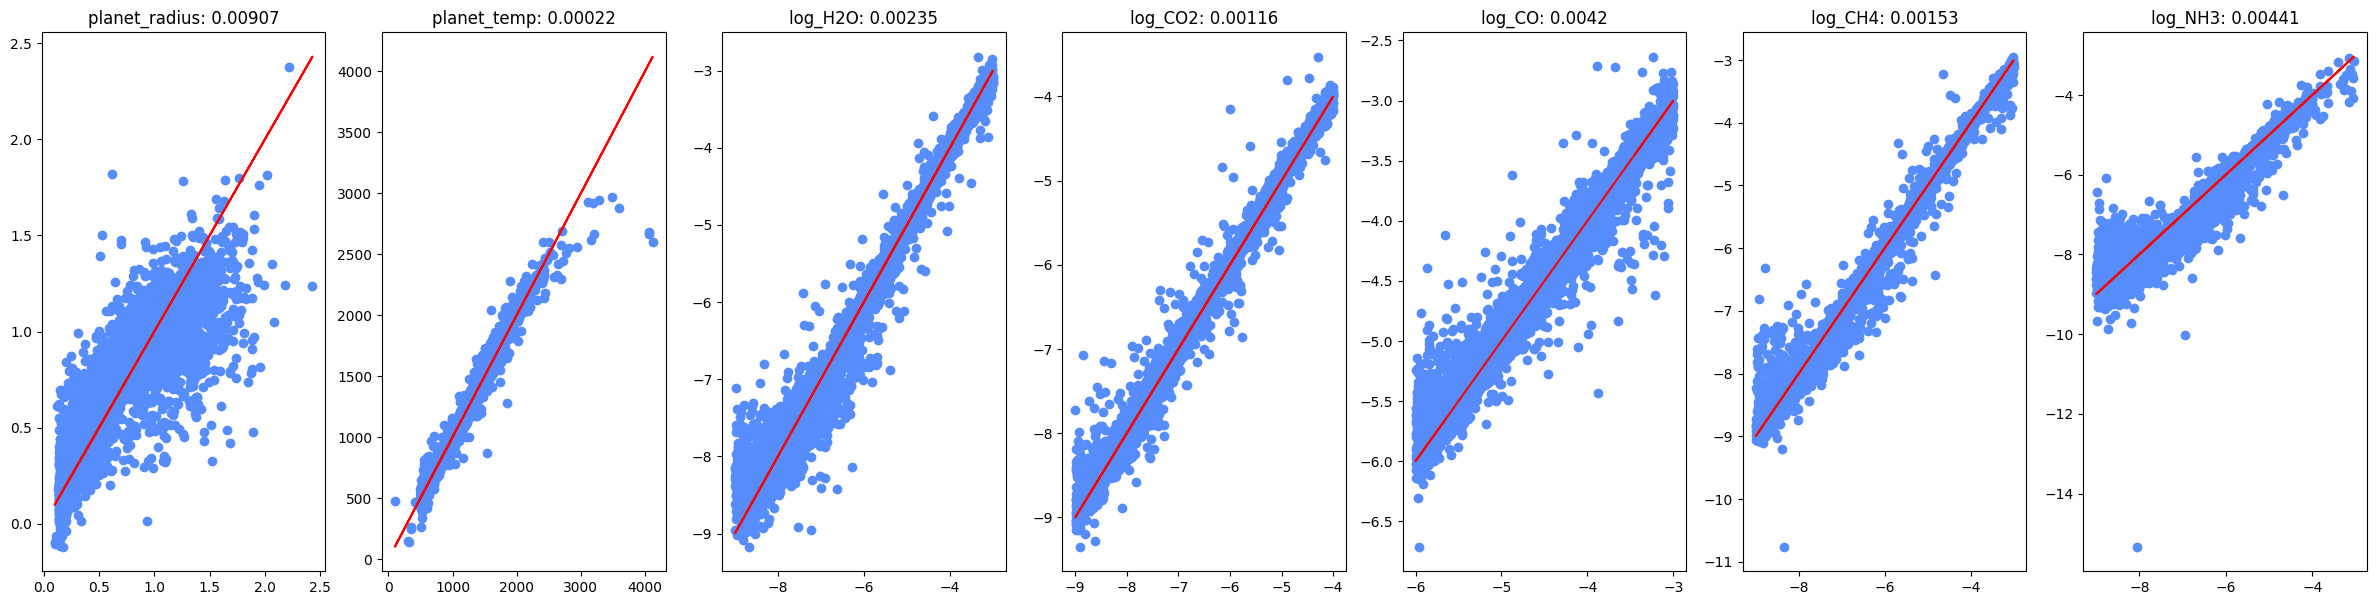

In [16]:
fig, axes = plt.subplots(1, n, figsize=(30,7))
axes_flat = axes.flatten()
for i in range(n):
    axes_flat[i].set_title(f'{param_names[i]}: {np.round(quality[i], 5)}')
    axes_flat[i].scatter(y_test_phys[:,i], y_pred_phys[:,i])
    axes_flat[i].plot(y_test_phys[:,i], y_test_phys[:,i], 'r')

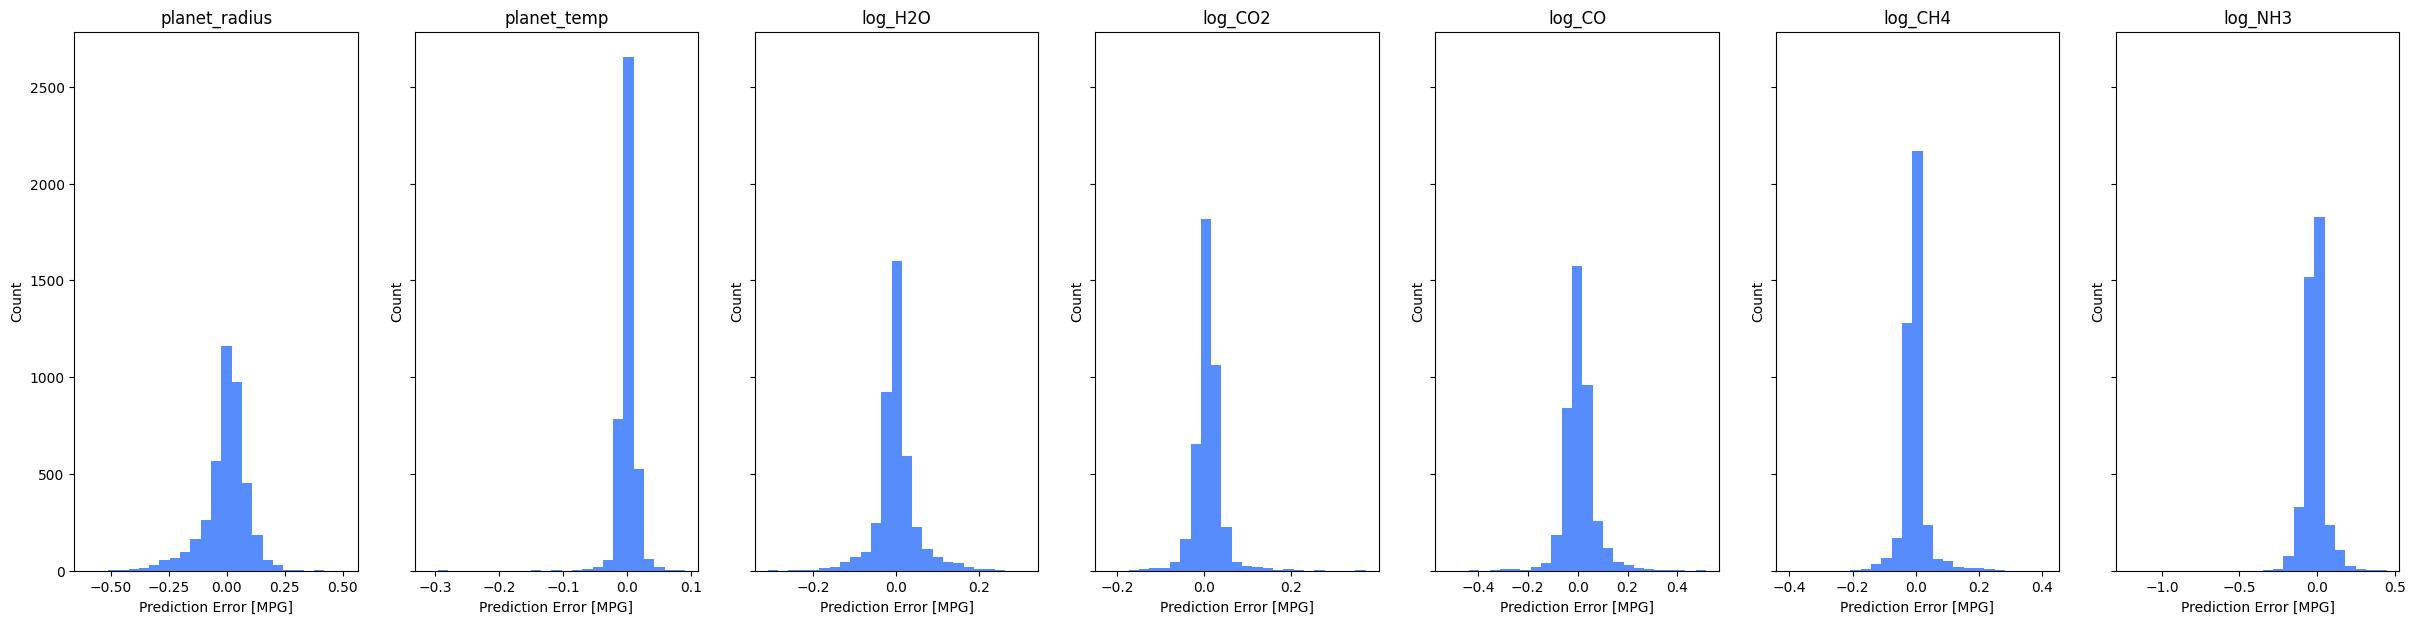

In [17]:
fig, ax = plt.subplots(1, n, figsize=(30,7), sharey=True)
for i in range(n):
  error = y_pred[:,i] - y_test[:,i]
  ax[i].hist(error, bins=25)
  ax[i].set_xlabel('Prediction Error [MPG]')
  ax[i].set_ylabel('Count')
  ax[i].set_title(f'{param_names[i]}')

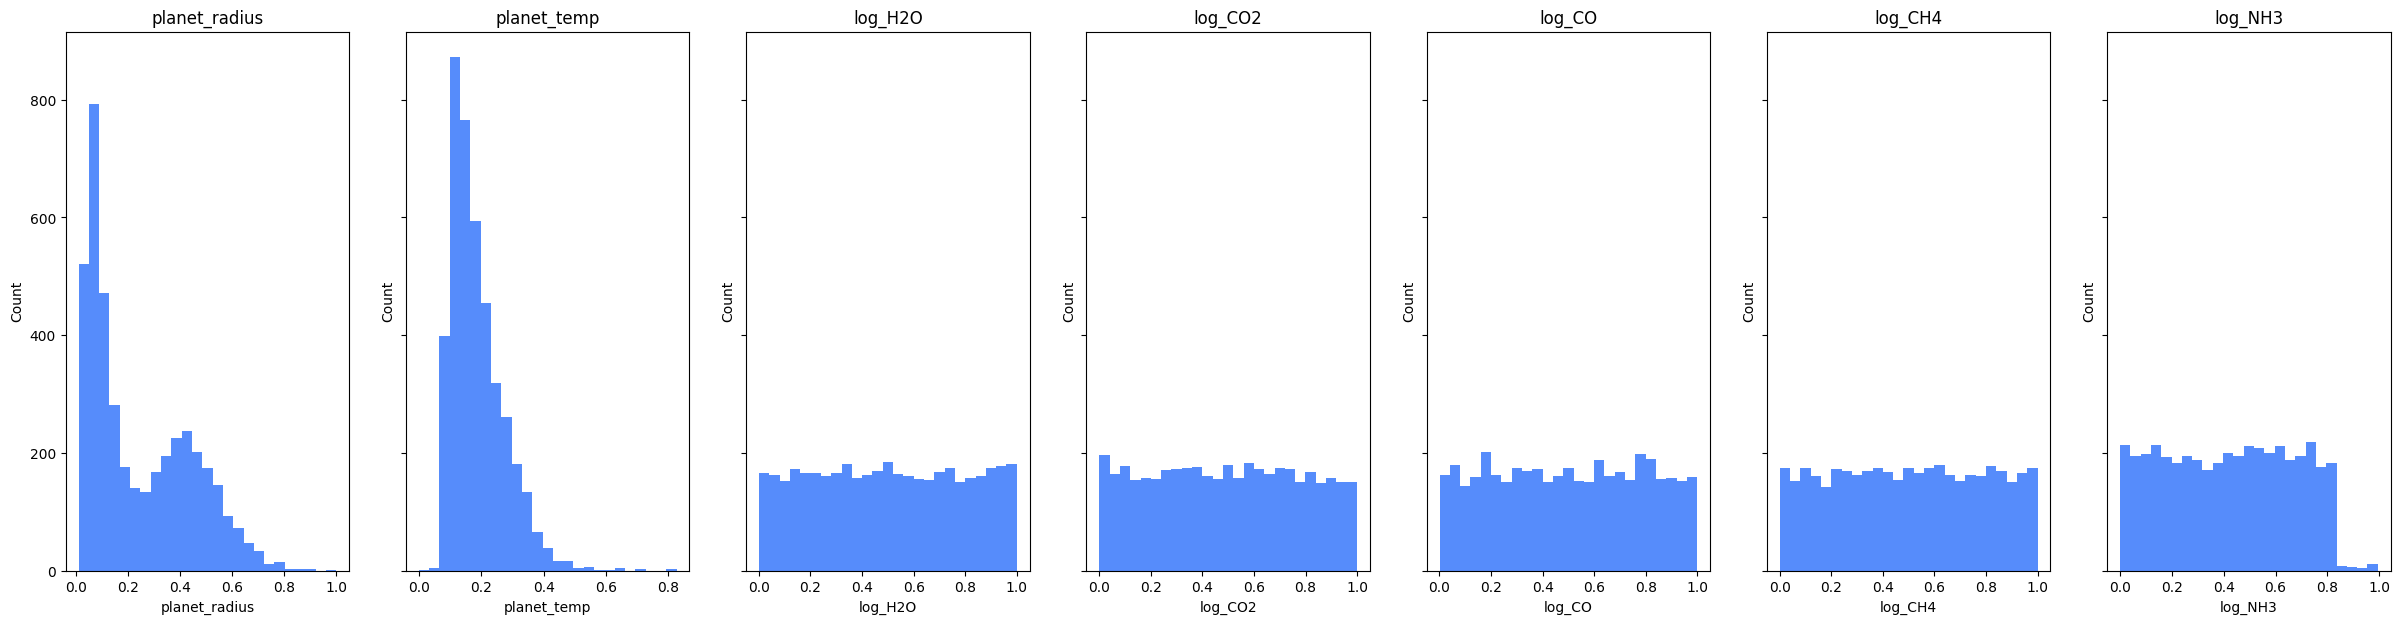

In [18]:
fig, ax = plt.subplots(1, n, figsize=(30,7), sharey=True)
for i, param in enumerate(param_names):
    ax[i].hist(y_test[:,i], bins=25)
    ax[i].set_xlabel(param)
    ax[i].set_ylabel('Count')
    ax[i].set_title(f'{param}')


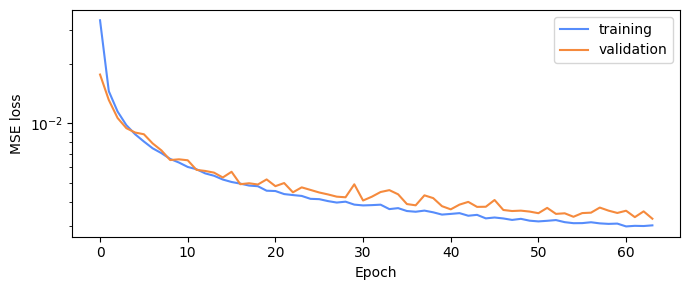

In [19]:
training_loss = history.history['loss']
validation_loss = history.history['val_loss']

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(training_loss, label='training')
ax.plot(validation_loss, label='validation')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE loss')
ax.set_yscale('log')
ax.legend()
plt.tight_layout()
plt.show()